In [52]:
# import necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from scipy.stats import chi2_contingency

plt.style.use("seaborn-v0_8")

In [53]:
# load dataset

DATA_PATH = Path("..") / ".." / ".." / "data" / "osmi-encoded.csv"
df = pd.read_csv(DATA_PATH)

df.head()

,Age,Gender,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,age_range
0,19,0,0,0,1,2,4,0,1,2,...,2,1,1,1,2,1,0,2,0,2
1,26,1,0,0,0,3,5,0,0,0,...,0,0,1,0,0,1,1,0,0,2
2,14,1,0,0,0,3,4,0,1,1,...,1,1,1,2,2,2,2,1,0,1
3,13,1,1,1,1,2,2,0,1,1,...,1,2,2,1,0,0,0,1,1,1
4,13,1,1,0,0,1,1,1,1,2,...,0,1,1,1,2,2,2,0,0,1


In [54]:
# basic structure of the dataset

df.info()

df.describe(include="all").transpose()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1257 entries, 0 to 1256
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Age                        1257 non-null   int64
 1   Gender                     1257 non-null   int64
 2   self_employed              1257 non-null   int64
 3   family_history             1257 non-null   int64
 4   treatment                  1257 non-null   int64
 5   work_interfere             1257 non-null   int64
 6   no_employees               1257 non-null   int64
 7   remote_work                1257 non-null   int64
 8   tech_company               1257 non-null   int64
 9   benefits                   1257 non-null   int64
 10  care_options               1257 non-null   int64
 11  wellness_program           1257 non-null   int64
 12  seek_help                  1257 non-null   int64
 13  anonymity                  1257 non-null   int64
 14  leave                   

,count,mean,std,min,25%,50%,75%,max
Age,1257.0,14.042164,7.156506,0.0,9.0,13.0,18.0,44.0
Gender,1257.0,0.818616,0.422915,0.0,1.0,1.0,1.0,2.0
self_employed,1257.0,0.121718,0.327090,0.0,0.0,0.0,0.0,1.0
family_history,1257.0,0.389817,0.487903,0.0,0.0,0.0,1.0,1.0
treatment,1257.0,0.505171,0.500172,0.0,0.0,1.0,1.0,1.0
work_interfere,1257.0,2.287987,1.595612,0.0,1.0,3.0,4.0,4.0
no_employees,1257.0,2.787589,1.738082,0.0,1.0,3.0,4.0,5.0
remote_work,1257.0,0.297534,0.457355,0.0,0.0,0.0,1.0,1.0
tech_company,1257.0,0.818616,0.385490,0.0,1.0,1.0,1.0,1.0
benefits,1257.0,1.053302,0.836769,0.0,0.0,1.0,2.0,2.0


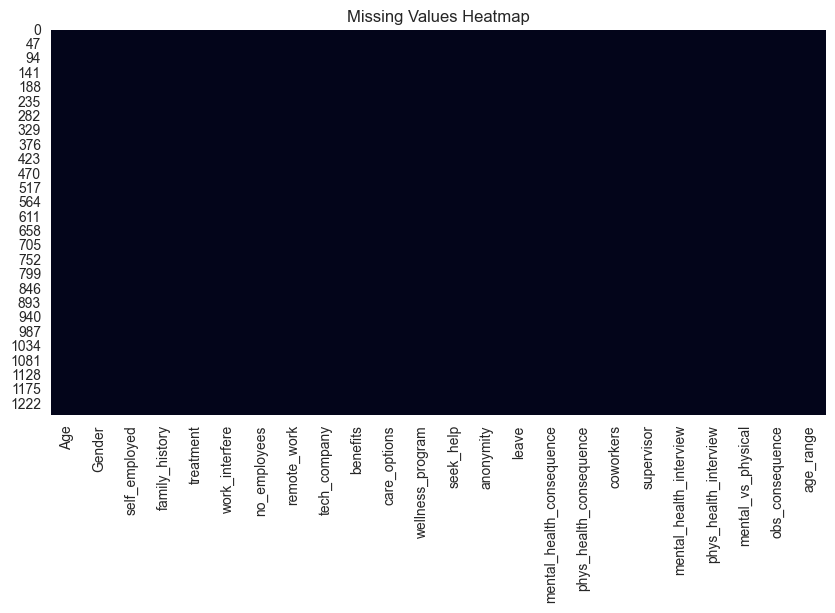

In [55]:
# missing values visualization

df.isna().sum()

plt.figure(figsize=(10,5))
sns.heatmap(df.isna(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

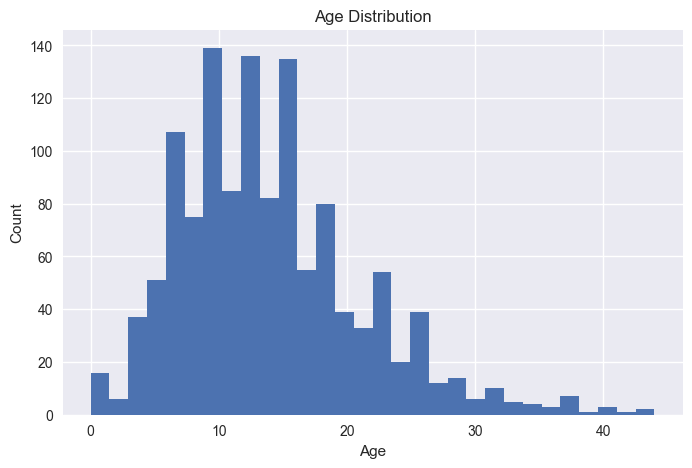

In [56]:
# age distribution

plt.figure(figsize=(8,5))
df["Age"].hist(bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

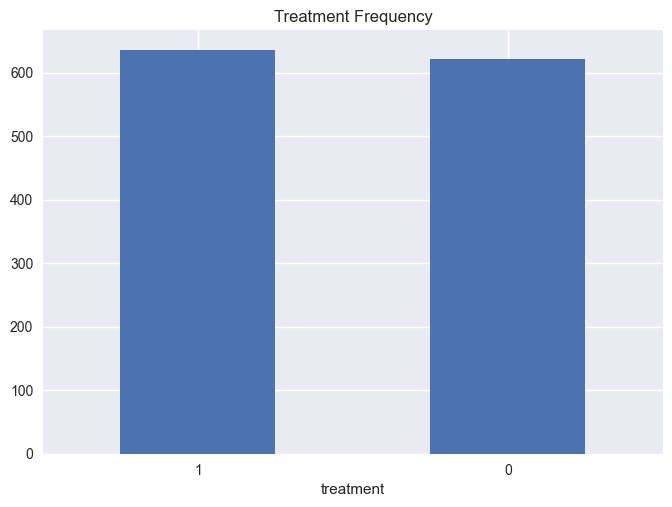

treatment
1    0.505171
0    0.494829
Name: proportion, dtype: float64

In [57]:
# treatment distribution

df["treatment"].value_counts().plot(kind="bar")
plt.title("Treatment Frequency")
plt.xticks(rotation=0)
plt.show()

# check class balance

df["treatment"].value_counts(normalize=True)


In [58]:
#exploring categorical variables

categorical_vars = [
    "Gender",
    "remote_work",
    "family_history",
    "benefits",
    "care_options",
    "anonymity",
    "coworkers",
    "supervisor",
    "no_employees",
]

for col in categorical_vars:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- Gender ---
Gender
1    991
0    247
2     19
Name: count, dtype: int64

--- remote_work ---
remote_work
0    883
1    374
Name: count, dtype: int64

--- family_history ---
family_history
0    767
1    490
Name: count, dtype: int64

--- benefits ---
benefits
2    475
0    408
1    374
Name: count, dtype: int64

--- care_options ---
care_options
0    501
2    442
1    314
Name: count, dtype: int64

--- anonymity ---
anonymity
0    819
2    373
1     65
Name: count, dtype: int64

--- coworkers ---
coworkers
1    774
0    260
2    223
Name: count, dtype: int64

--- supervisor ---
supervisor
2    514
0    393
1    350
Name: count, dtype: int64

--- no_employees ---
no_employees
4    290
2    289
5    282
1    176
0    160
3     60
Name: count, dtype: int64


In [59]:
#conditional probability 

def conditional_probability(df, outcome, condition):
    subset = df[df[condition] == 1]
    return subset[outcome].mean()

In [60]:
cp_single = {
    "family_history": conditional_probability(df, "treatment", "family_history"),
    "benefits": conditional_probability(df, "treatment", "benefits"),
    "anonymity": conditional_probability(df, "treatment", "anonymity"),
    "remote_work": conditional_probability(df, "treatment", "remote_work"),
    "supervisor": conditional_probability(df, "treatment", "supervisor"),
}

pd.DataFrame.from_dict(cp_single, orient="index", columns=["P(Treatment=1 | X=1)"])

,P(Treatment=1 | X=1)
family_history,0.740816
benefits,0.483957
anonymity,0.584615
remote_work,0.524064
supervisor,0.514286


In [62]:
# two variables conditional probability

def conditional_two(df, outcome, cond1, cond2):
    subset = df[(df[cond1] == 1) & (df[cond2] == 1)]
    return subset[outcome].mean()

cp_two = {
    "family_history + benefits": conditional_two(df, "treatment", "family_history", "benefits"),
    "anonymity + supervisor": conditional_two(df, "treatment", "anonymity", "supervisor"),
    "remote_work + family_history": conditional_two(df, "treatment", "remote_work", "family_history")
}

pd.DataFrame.from_dict(cp_two, orient="index", columns=["P(Treatment=1 | X=1, Y=1)"])

,"P(Treatment=1 | X=1, Y=1)"
family_history + benefits,0.731707
anonymity + supervisor,0.615385
remote_work + family_history,0.758389


In [63]:
# cramer's V calculation

def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    return np.sqrt(chi2 / (n * (min(confusion.shape)-1)))


In [65]:
# calculate cramer's V for categorical variables against treatment

cv_results = {}

for col in categorical_vars:
    cv_results[col] = cramers_v(df[col], df["treatment"])

cv_df = pd.DataFrame.from_dict(cv_results, orient="index", columns=["Cramér's V"])
cv_df.sort_values("Cramér's V", ascending=False)

,Cramér's V
family_history,0.375083
care_options,0.272828
benefits,0.225511
Gender,0.198666
anonymity,0.142991
no_employees,0.081575
coworkers,0.066421
supervisor,0.038919
remote_work,0.022853
